### Nanocomp - 2025.02 - Prof. Omar
---
<p> 
Optimizing quantum wells for quantum bragg mirror detectors via genetic algorithms(NSGA-II).
</p>

- Guilherme Rigacci
- Marco Túlio Mata
- Lucas Gabriel

---

#### 1. _AUTOMATED RUN_

In [4]:
%%capture

import include.run_prog as prog

ex1 = [4, 2e-9, 7e-9, 5e-9, 1, 2e-9, 7e-9]
param = ex1
if(len(param) != 7):
    raise ValueError("Parameter list must have exactly 7 elements.")
out_dir = prog.run_qbmd(param[0], param[1], param[2], param[3], param[4], param[5], param[6], create_param_folder=True)
print("Outputs in:", out_dir)

#### 2. _VISUALIZATION_

────────────────────────────────────────────────────────────
Files in /home/mark/nano.compQBMD/linux_executable/manual_runs/05x2.0_7.0__2.0__01x2.0_7.0
────────────────────────────────────────────────────────────
Energy_SL                 : True
FimPrograma               : True
OscStr_SL                 : True
Photocurrent_SL           : True
Transmission_SL           : True
Potencial_SL              : True
Wavefunction_SL           : True

────────────────────────────────────────────────────────────
FimPrograma.txt value
────────────────────────────────────────────────────────────
raw                       : 45.981580999999998
as_float                  : 45.981581

────────────────────────────────────────────────────────────
Energy_SL.txt summary
────────────────────────────────────────────────────────────
num_points                : 45
min (eV?)                 : 284.5690032357867
max (eV?)                 : 696.2440392029428
mean                      : 534.8775760989406
median      

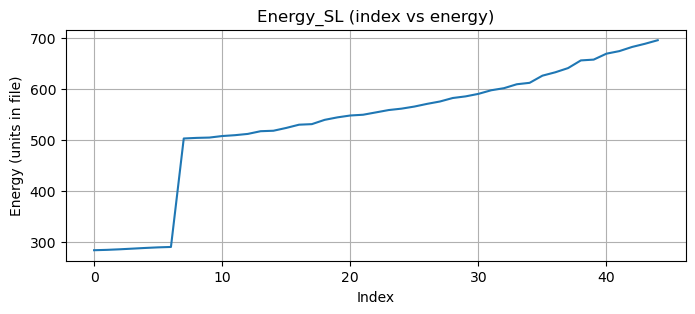

────────────────────────────────────────────────────────────
Photocurrent_SL metrics
────────────────────────────────────────────────────────────
num_peaks                 : 2
peak_energy               : 321.8000200798737
peak_value                : 1.637427097657734e-09
peak_area                 : 9.16040223833341e-09
total_abs_area            : 3.1237610001520265e-08
prominence_ratio          : 0.29324913903104605
Q_factor                  : 51.90322580645155
secondary_peaks_ratio     : 0.10576995843303558
integrated_QE             : 2.1158387617754156e-08



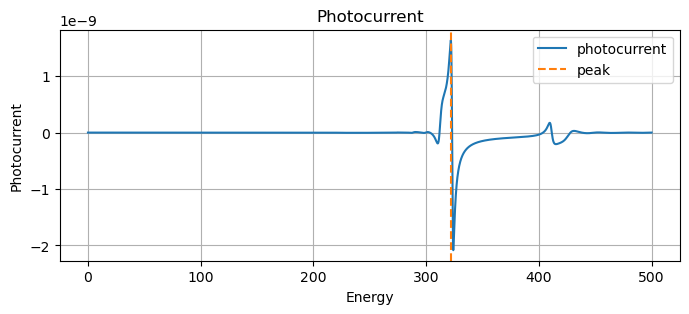

────────────────────────────────────────────────────────────
OscStr_SL.txt summary
────────────────────────────────────────────────────────────
shape                     : (44, 2)
x min/max                 : (0.7192575011907427, 411.67503596715613)
y min/max                 : (1.1592213326095649e-06, 0.42456767907002646)



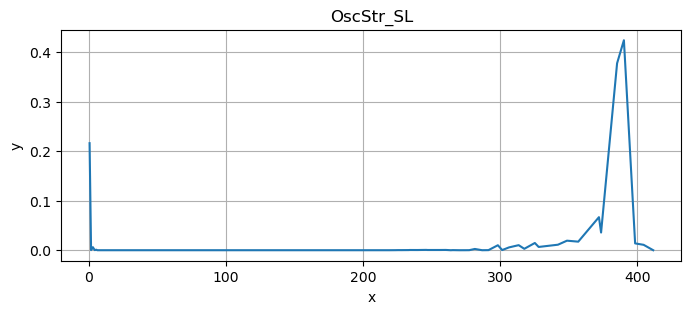

────────────────────────────────────────────────────────────
Transmission_SL.txt summary
────────────────────────────────────────────────────────────
shape                     : (4999, 2)
x min/max                 : (0.10000000623986131, 499.90003119306675)
y min/max                 : (3.32013405e-22, 1.0)



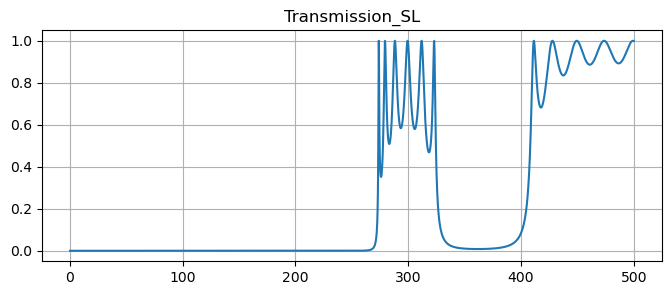

────────────────────────────────────────────────────────────
Potencial_SL.txt summary
────────────────────────────────────────────────────────────
shape                     : (1921, 2)
x min/max                 : (-95.0, 97.00000286102295)
y min/max                 : (0.0, 503.0)



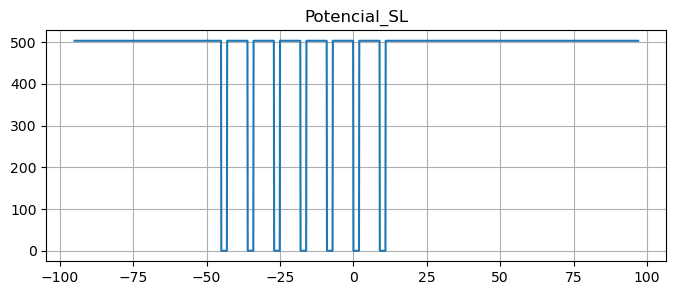

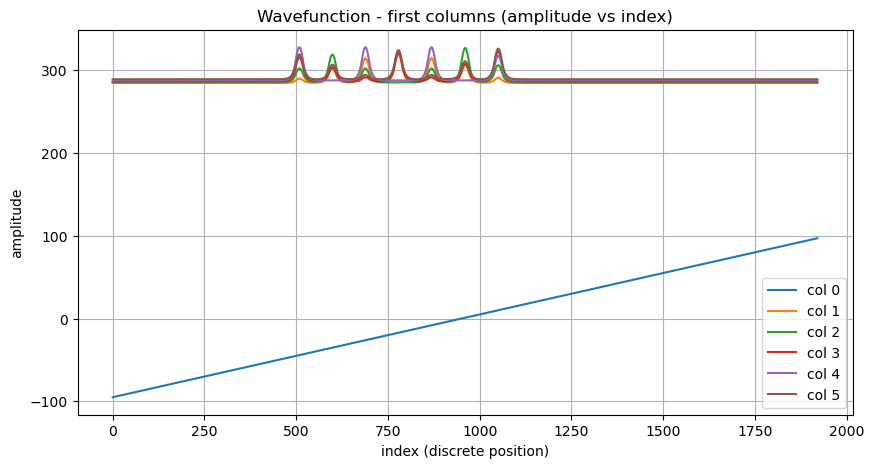

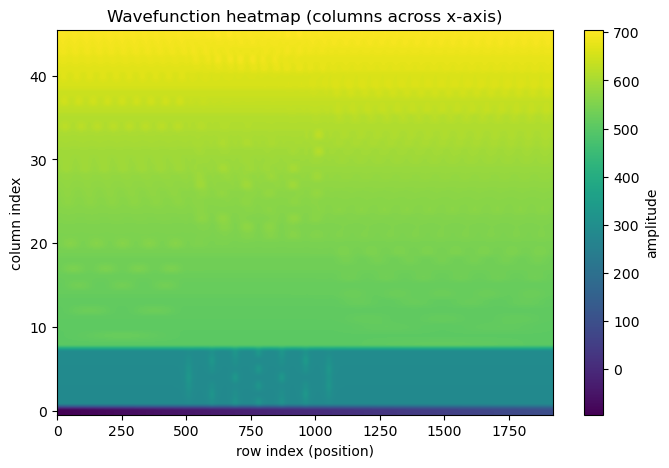

In [5]:
import include.visualize as viz
out_dir = "/home/mark/nano.compQBMD/linux_executable/manual_runs/05x2.0_7.0__2.0__01x2.0_7.0/"
res = viz.visualize_all(out_dir, show=True)

### 3. _GENETIC ALGORITHM_

In [ ]:
import sys
from include.run_opt import run_optimization as run_ga

if __name__ == "__main__":
    try:
        print("Iniciando otimização GA multi-objetivo...")
        
        # Example for stating point
        initial_population_csv="../linux_executable/optimization_results/pareto_full_guilherme4320.csv"
        
        # You may want to clear any intermediate_sim_*.csv before running
        # results = run_ga() 
        results = run_ga(initial_population_csv)
        
        print("\n Otimização concluída com sucesso!")
        sys.exit(0)
    except KeyboardInterrupt:
        print("\n  Otimização interrompida pelo usuário")
        sys.exit(1)
    except Exception as e:
        print(f"\n:c Error durante a otimização: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


### 4. _PARETO_ _FRONTS_

In [6]:
# Load Pareto front results using pareto_extract module
from include.pareto_extract import load_pareto_results, display_best_solutions, visualize_pareto_2d, visualize_pareto_3d, get_statistics

# Load the most recent optimization results
try:
    df = load_pareto_results()
    print("\nColumns:", list(df.columns))
    print("\nFirst 5 solutions:")
    display(df.head())
except FileNotFoundError as e:
    print(e)
    df = None

Loaded 48 Pareto-optimal solutions from /home/mark/nano.compQBMD/linux_executable/optimization_results/pareto_full_guilherme4320.csv

Columns: ['RW', 'RQWt', 'RQBt', 'MQWt', 'LW', 'LQWt', 'LQBt', 'max_energy_eV', 'max_photocurrent', 'quality_factor', 'prominence', 'constraint']

First 5 solutions:


,RW,RQWt,RQBt,MQWt,LW,LQWt,LQBt,max_energy_eV,max_photocurrent,quality_factor,prominence,constraint
0,9,2.498410,12.401169,4.117218,8,1.005074,14.907422,3.372314,2.767254e-12,1594.771930,1.000000,-2.526144
1,8,1.331986,13.195380,2.151231,5,3.184903,13.477755,2.617138,3.087518e-08,2354.065955,0.999926,-0.233245
2,9,1.857376,14.164356,1.812588,8,1.212458,13.638487,6.037001,9.949766e+08,0.000000,1.000000,-0.014131
3,9,4.878733,13.755026,2.353180,9,1.624111,14.837555,3.293492,2.892840e+13,0.000000,1.000000,-0.143070
4,9,1.442561,13.219823,2.045213,5,7.218187,14.139735,2.709790,5.023175e-09,2138.432213,0.996589,-0.016652


In [7]:
# Display summary statistics
if df is not None:
    stats = get_statistics(df)
    display(stats)

,objective,min,max,mean,std
0,Energia do Pico (eV),2.617138e+00,1.288981e+01,5.561477e+00,2.936617e+00
1,Intensidade da Fotocorrente,2.767254e-12,2.892840e+13,6.072467e+11,4.174895e+12
2,Fator de Qualidade,0.000000e+00,2.354066e+03,1.178752e+03,7.639451e+02
3,Proeminência,9.965890e-01,1.000000e+00,9.996733e-01,8.661097e-04


In [8]:
# Display best solutions for each objective
if df is not None:
    display_best_solutions(df)


MELHORES SOLUÇÕES POR OBJETIVO

Melhor Energia do Pico (eV):
   Valor: 12.889812
   Parâmetros: RW=9.00, RQWt=1.05, RQBt=13.76, MQWt=2.24, LW=5.00, LQWt=2.25, LQBt=14.26
   Outros objetivos:
     - Intensidade da Fotocorrente: 2005.362000
     - Fator de Qualidade: 0.000000
     - Proeminência: 1.000000

Melhor Intensidade da Fotocorrente:
   Valor: 28928400000000.000000
   Parâmetros: RW=9.00, RQWt=4.88, RQBt=13.76, MQWt=2.35, LW=9.00, LQWt=1.62, LQBt=14.84
   Outros objetivos:
     - Energia do Pico (eV): 3.293492
     - Fator de Qualidade: 0.000000
     - Proeminência: 1.000000

Melhor Fator de Qualidade:
   Valor: 2354.065955
   Parâmetros: RW=8.00, RQWt=1.33, RQBt=13.20, MQWt=2.15, LW=5.00, LQWt=3.18, LQBt=13.48
   Outros objetivos:
     - Energia do Pico (eV): 2.617138
     - Intensidade da Fotocorrente: 0.000000
     - Proeminência: 0.999926

Melhor Proeminência:
   Valor: 1.000000
   Parâmetros: RW=9.00, RQWt=2.50, RQBt=12.40, MQWt=4.12, LW=8.00, LQWt=1.01, LQBt=14.91
   Outro

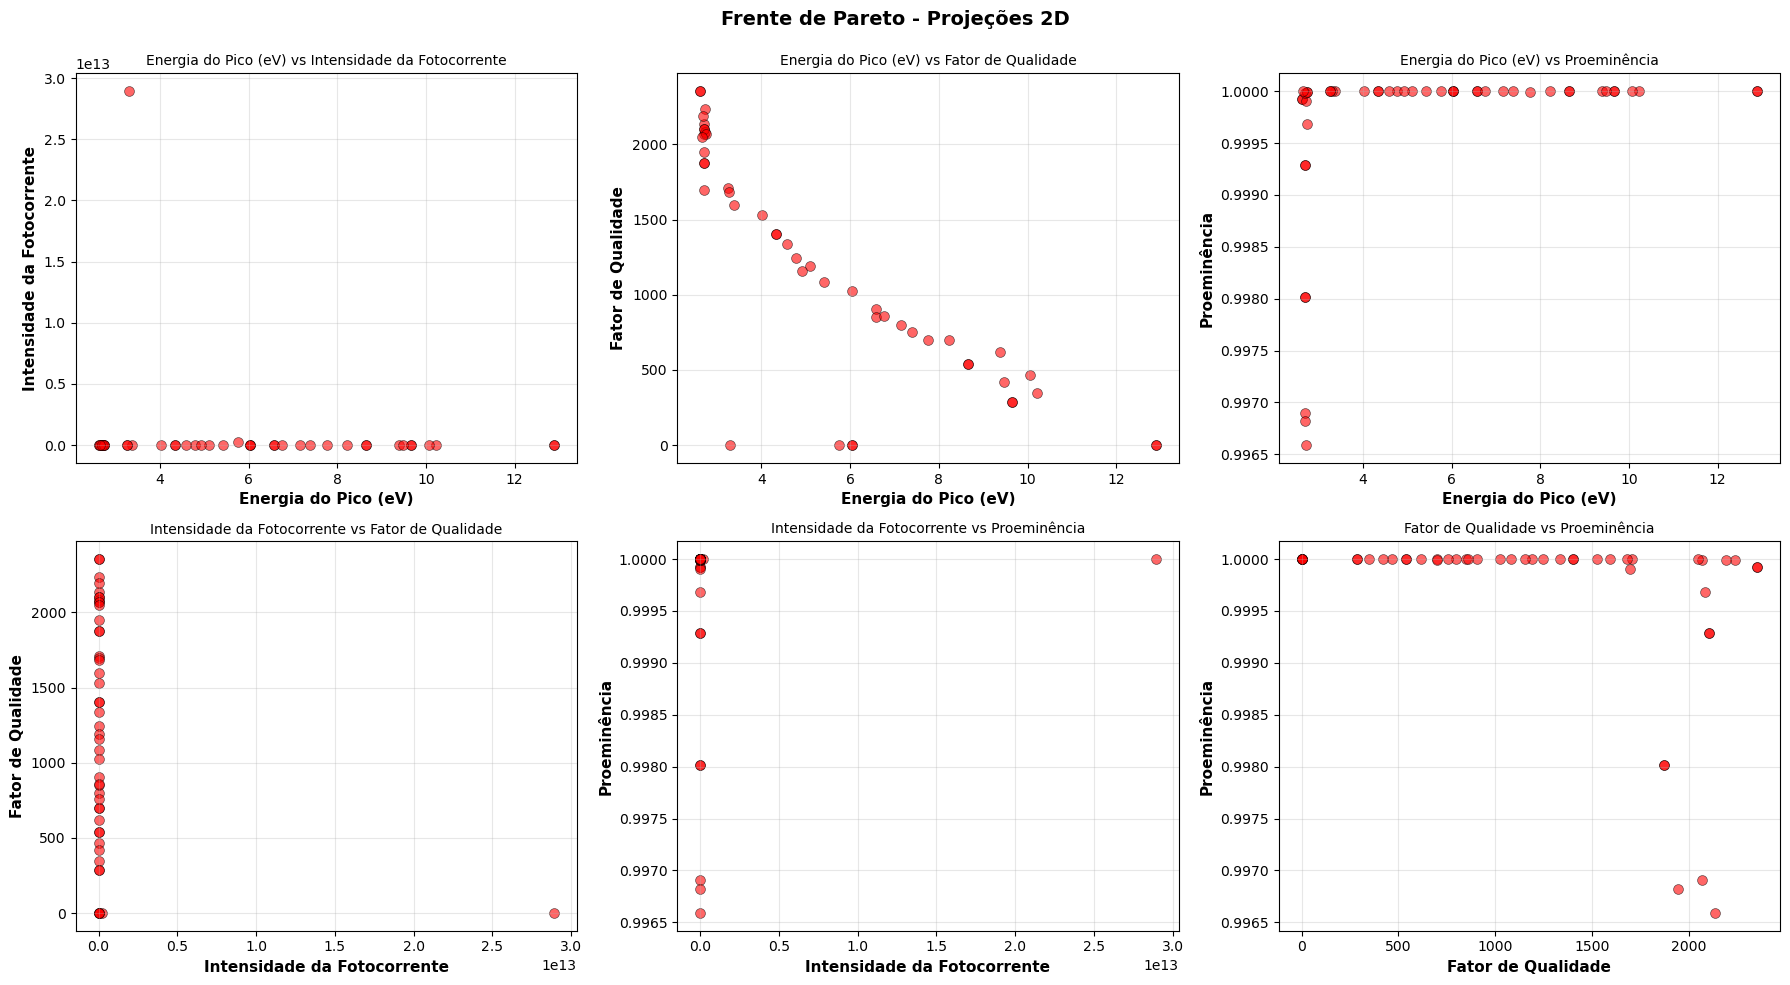

In [9]:
# projections
if df is not None:
    visualize_pareto_2d(df, show=True, save=False)

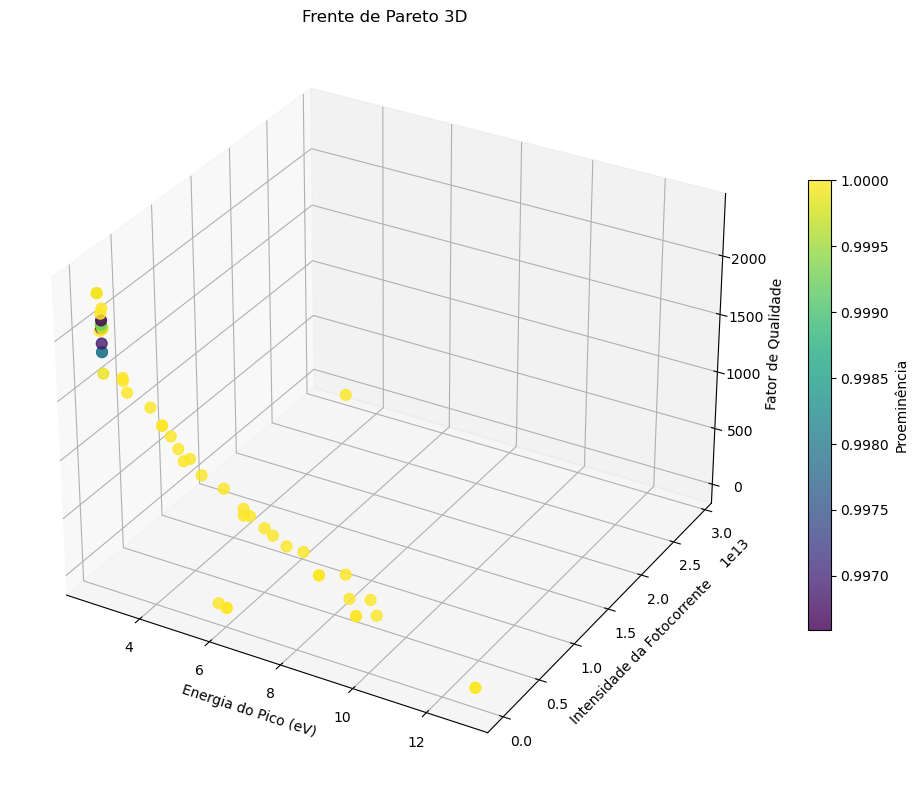

In [10]:
# representing 4 goals
if df is not None:
    visualize_pareto_3d(df, show=True, save=False)

### 5. _CONCLUSIONS_ - Parameter-Objective Relationships

In [11]:
# Analyze relationships between input parameters and objectives
from include.pareto_extract import analyze_parameter_objective_relationships, print_parameter_analysis, get_conclusions_markdown

if df is not None:
    # Perform analysis on Pareto front data
    analysis = analyze_parameter_objective_relationships(df, top_percent=25)
    
    # Print detailed analysis
    print_parameter_analysis(analysis)


ANÁLISE DE RELAÇÕES PARÂMETROS-OBJETIVOS

────────────────────────────────────────────────────────────────────────────────
GOAL: Energia do Pico (eV)
   (Análise dos top 12 indivíduos)
────────────────────────────────────────────────────────────────────────────────

Parâmetro  │          Global           │      Top Performers       │   Corr  
           │   Min      Max      Mean   │   Min      Max      Mean   │         
───────────┼───────────────────────────┼───────────────────────────┼─────────
RW         │     8.00     9.00     8.85 │     9.00     9.00     9.00 │  0.346 
RQWt       │     1.05     4.98     1.95 │     1.05     2.76     2.23 │  0.174 
RQBt       │     6.65    14.94    13.58 │    12.45    14.16    13.77 │  0.031 
MQWt       │     1.75     4.39     2.65 │     2.04     2.77     2.43 │ -0.391 
LW         │     4.00     9.00     5.94 │     4.00     9.00     5.58 │ -0.013 
LQWt       │     1.00     7.82     2.81 │     1.01     2.25     1.27 │ -0.592 ↓
LQBt       │    12.83

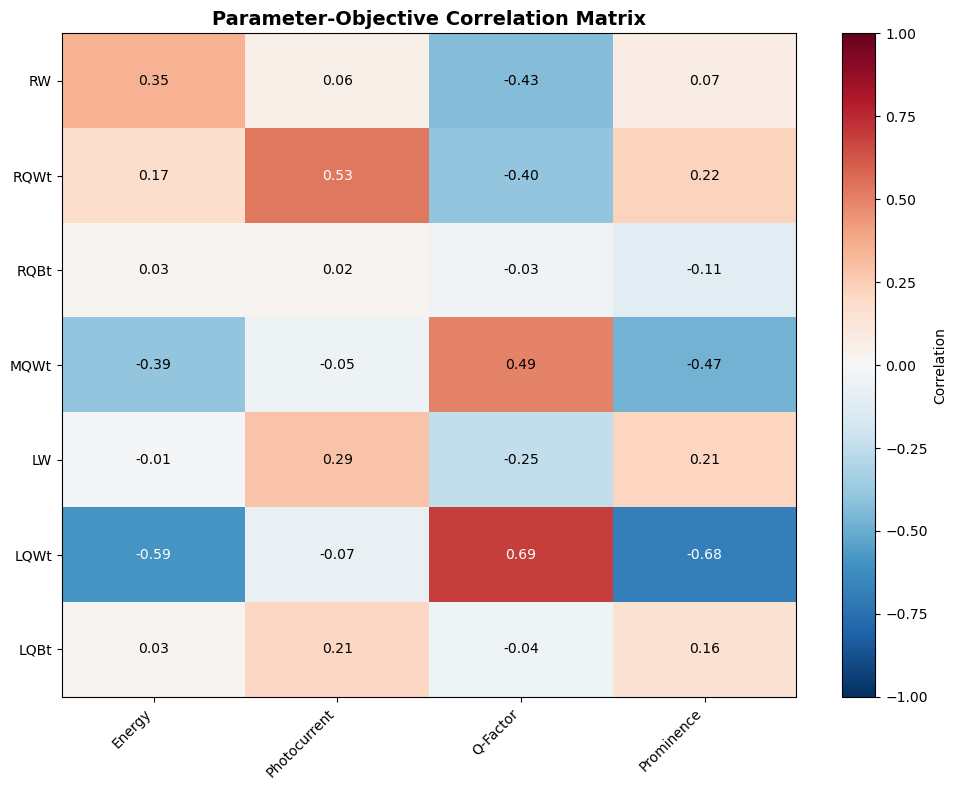

In [12]:
# visualize correlacoes parametro-objetivo
import matplotlib.pyplot as plt
import numpy as np

if df is not None:
    param_cols = ['RW', 'RQWt', 'RQBt', 'MQWt', 'LW', 'LQWt', 'LQBt']
    obj_cols = ['max_energy_eV', 'max_photocurrent', 'quality_factor', 'prominence']
    
    # Calculate correlation matrix
    all_cols = param_cols + obj_cols
    corr_matrix = df[all_cols].corr()
    
    # Extract only parameter-objective correlations
    param_obj_corr = corr_matrix.loc[param_cols, obj_cols]
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(param_obj_corr.values, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    
    # Labels
    ax.set_xticks(range(len(obj_cols)))
    ax.set_xticklabels(['Energy', 'Photocurrent', 'Q-Factor', 'Prominence'], rotation=45, ha='right')
    ax.set_yticks(range(len(param_cols)))
    ax.set_yticklabels(param_cols)
    
    # Add correlation values as text
    for i in range(len(param_cols)):
        for j in range(len(obj_cols)):
            val = param_obj_corr.iloc[i, j]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=10)
    
    plt.colorbar(im, label='Correlation')
    plt.title('Parameter-Objective Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### AI ANALYZE

In [13]:
from IPython.display import Markdown, display

if df is not None:
    conclusions_md = get_conclusions_markdown(analysis)
    display(Markdown(conclusions_md))

## 📋 Conclusões da Análise do Pareto Front
### Relações entre Parâmetros de Entrada e Objetivos

#### Energia do Pico (eV)
Análise baseada nos top 12 indivíduos do Pareto front.
**Correlações positivas (valores maiores ajudam):**
- `RW`: correlação = 0.346

**Correlações negativas (valores menores ajudam):**
- `LQWt`: correlação = -0.592
- `MQWt`: correlação = -0.391

**Faixas de valores preferidas nos melhores indivíduos:**
- `RW`: [9.00, 9.00]
- `RQWt`: [1.05, 2.76]
- `RQBt`: [12.45, 14.16]
- `MQWt`: [2.04, 2.77]
- `LQWt`: [1.01, 2.25]

#### Intensidade da Fotocorrente
Análise baseada nos top 12 indivíduos do Pareto front.
**Correlações positivas (valores maiores ajudam):**
- `RQWt`: correlação = 0.527

**Faixas de valores preferidas nos melhores indivíduos:**
- `RW`: [9.00, 9.00]
- `MQWt`: [1.75, 2.77]
- `LQWt`: [1.01, 2.25]

#### Fator de Qualidade
Análise baseada nos top 12 indivíduos do Pareto front.
**Correlações positivas (valores maiores ajudam):**
- `LQWt`: correlação = 0.690
- `MQWt`: correlação = 0.493

**Correlações negativas (valores menores ajudam):**
- `RW`: correlação = -0.430
- `RQWt`: correlação = -0.395

**Faixas de valores preferidas nos melhores indivíduos:**
- `RQWt`: [1.10, 1.47]
- `RQBt`: [13.20, 14.94]

#### Proeminência
Análise baseada nos top 12 indivíduos do Pareto front.

**Correlações negativas (valores menores ajudam):**
- `LQWt`: correlação = -0.682
- `MQWt`: correlação = -0.473

**Faixas de valores preferidas nos melhores indivíduos:**
- `RQBt`: [12.40, 14.16]
- `LQWt`: [1.01, 3.12]

---
*Nota: Correlações acima de |0.3| são consideradas relevantes. Faixas preferidas indicam parâmetros onde os melhores indivíduos convergem.*
